# Admixture-Graph Validation Pipeline

**Goal.** Prove the end-to-end machinery works *before* any ML is layered on: define a known
admixture graph → simulate real SNP genotypes under it (msprime) → compute f-statistics
(ADMIXTOOLS 2) → infer a graph from those statistics → check the inference recovers the truth.

This notebook is the **validation backbone** for a later project that trains a deep-learning model
to predict admixture graphs from f-statistics. The f-statistics computed here are the seam where a
fast analytic generator will later plug in for large-scale training-data generation.

**Pipeline**

| Step | What | Tool |
|---|---|---|
| 0 | Environment setup & checks | python venv + R |
| 1 | Define the true admixture graph | Python |
| 2 | Build the msprime demography | msprime |
| 3 | Simulate SNP genotypes | msprime |
| 4 | Export genotypes to PLINK | snputils |
| 5 | Compute f2/f3 (+ admixture-signal gate) | ADMIXTOOLS 2 (R) |
| 6 | qpgraph sanity-check on the TRUE topology | ADMIXTOOLS 2 (R) |
| 7 | find_graphs blind topology search | ADMIXTOOLS 2 (R) |
| 8 | Compare recovered graph(s) to truth → PASS/FAIL | Python (networkx) |

The graph: **6 sampled populations = 5 ingroup (P1–P5) + 1 outgroup (O)**, with a single
admixture event at **P3**. Five ingroup populations plus the outgroup is comfortably above the
n ≥ 5 threshold needed to identify one admixture event.

## Step 0 — Environment setup

**What this does.** Imports the Python stack and locates `Rscript` + the ADMIXTOOLS 2 R package,
then prints a readiness checklist. It also defines global config (paths, RNG seed, simulation size).

**What you should expect.** A table of versions and `OK` for every dependency. If anything is
missing, the install commands are in the cell below.

> **Toolchain note (macOS).** Nothing here was preinstalled. The reproducible setup used:
> - Python venv: `python -m venv .venv && .venv/bin/pip install "numpy<2" scipy pandas matplotlib msprime tskit networkx snputils jupyter ipykernel`
> - R: `brew install r` and `brew install gcc` (for gfortran).
> - **ADMIXTOOLS 2:** brew's R 4.6 defaults to `-std=gnu23`, which Apple clang 15 rejects, so set
>   `~/.R/Makevars` to `CC = clang -std=gnu17` / `CC23 = clang -std=gnu17`, then
>   `Rscript -e 'install.packages("pgenlibr"); remotes::install_github("uqrmaie1/admixtools", dependencies=NA)'`.

In [1]:
import os, sys, json, subprocess, shutil, tempfile, textwrap
from pathlib import Path
import numpy as np

# ---- global config ----
PROJECT = Path.cwd()
WORK = PROJECT / "artifacts"; WORK.mkdir(parents=True, exist_ok=True)  # all generated files land here
RSCRIPT = shutil.which("Rscript") or "/opt/homebrew/bin/Rscript"
SEED = 42
N_DIP = 10            # diploid samples per population
SEQLEN = 1e8          # bp simulated (≈ 80–90k SNPs at these params)
REC = 1e-8            # recombination rate (per bp per generation)
MU  = 1.25e-8         # mutation rate

def check(label, ok, extra=""):
    print(f"  [{'OK ' if ok else 'XX '}] {label:<22} {extra}")

print("Python:", sys.version.split()[0])
import msprime, tskit, networkx, snputils
check("msprime", True, msprime.__version__)
check("tskit", True, tskit.__version__)
check("networkx", True, networkx.__version__)
check("snputils", True)
check("numpy<2", np.__version__.startswith("1."), np.__version__)
rs = subprocess.run([RSCRIPT, "--version"], capture_output=True, text=True)
check("Rscript", rs.returncode == 0, (rs.stdout or rs.stderr).strip().split("\n")[0])
at = subprocess.run([RSCRIPT, "-e",
     'cat(as.character(packageVersion("admixtools")))'], capture_output=True, text=True)
check("ADMIXTOOLS 2", at.returncode == 0 and at.stdout.strip()[0:1].isdigit(), at.stdout.strip())
print("\nConfig: seed=%d  samples/pop=%d  seqlen=%.0e  Rscript=%s" % (SEED, N_DIP, SEQLEN, RSCRIPT))

def run_r(r_code, label="r"):
    # Write an R script and run it via Rscript; raise on failure, return stdout.
    f = WORK / f"_{label}.R"
    f.write_text(r_code)
    p = subprocess.run([RSCRIPT, str(f)], capture_output=True, text=True)
    if p.returncode != 0:
        print(p.stdout); print(p.stderr)
        raise RuntimeError(f"R step '{label}' failed")
    return p.stdout

Python: 3.12.4


  [OK ] msprime                1.3.4
  [OK ] tskit                  0.6.4
  [OK ] networkx               3.6.1
  [OK ] snputils               
  [OK ] numpy<2                1.26.4
  [OK ] Rscript                Rscript (R) version 4.6.1 (2026-06-24)
  [OK ] ADMIXTOOLS 2           2.0.10

Config: seed=42  samples/pop=10  seqlen=1e+08  Rscript=/opt/homebrew/bin/Rscript


## Step 1 — Define the true admixture graph

**What this does.** Encodes the ground-truth graph as a single Python data structure — the one
source of truth that drives both the simulation (Steps 2–4) and the qpgraph sanity check (Step 6).

The graph (parent → child; **P3 has two parents → the admixture event**):

```
                root
                /  \
               O    anc
                    /  \
                anc_L   anc_R
                /  \     /  \
              P1  anc_L2 P4  anc_R2
                   /  \      /  \
                  P2  srcA  P5  srcB
                        \   /
                         P3 = α·srcA + (1-α)·srcB
```

Node **times** (generations) are chosen so the admixture is *detectable*: the two sources srcA and
srcB sit on deeply-diverged lineages (common ancestor `anc` at 1800 gen) and the admixture is recent
(200 gen) so P3's own drift is small. Step 5 verifies this produced a clearly negative
f3(P3; P2, P5) before we trust the search.

**What you should expect.** `[step1] graph OK …` confirming 6 sampled pops and P3's two parents.

In [2]:
GRAPH = dict(
    Ne=1000,
    alpha=0.4,                       # P3 = alpha*srcA + (1-alpha)*srcB
    leaves=["O", "P1", "P2", "P3", "P4", "P5"],
    outgroup="O",
    admixed="P3",
    edges=[
        ("root", "O"), ("root", "anc"),
        ("anc", "anc_L"), ("anc", "anc_R"),
        ("anc_L", "P1"), ("anc_L", "anc_L2"),
        ("anc_R", "P4"), ("anc_R", "anc_R2"),
        ("anc_L2", "P2"), ("anc_L2", "srcA"),
        ("anc_R2", "P5"), ("anc_R2", "srcB"),
        ("srcA", "P3"), ("srcB", "P3"),
    ],
    times=dict(P3_adm=200, anc_L2=600, anc_R2=600, anc_L=1000, anc_R=1000, anc=1800, root=2600),
    # backbone clades over non-admixed leaves (used for the lenient Step-8 check)
    expected_clades=[{"P1", "P2"}, {"P4", "P5"}],
)

def verify_graph(g):
    from collections import defaultdict
    indeg = defaultdict(int); children = defaultdict(list); parents = defaultdict(list)
    for u, v in g["edges"]:
        indeg[v] += 1; children[u].append(v); parents[v].append(u)
    assert indeg[g["admixed"]] == 2, "admixed node must have exactly 2 parents"
    assert set(parents["P3"]) == {"srcA", "srcB"}
    assert set(children["anc_L2"]) == {"P2", "srcA"} and set(children["anc_R2"]) == {"P5", "srcB"}
    leaves = [n for n in {y for _, y in g["edges"]} | {x for x, _ in g["edges"]} if n not in children]
    assert set(leaves) == set(g["leaves"]), f"leaf set mismatch: {sorted(leaves)}"
    print(f"[step1] graph OK: {len(g['leaves'])} sampled pops = {len(g['leaves'])-1} ingroup "
          f"+ 1 outgroup ({g['outgroup']}); 1 admixture at {g['admixed']} (alpha={g['alpha']})")
verify_graph(GRAPH)

[step1] graph OK: 6 sampled pops = 5 ingroup + 1 outgroup (O); 1 admixture at P3 (alpha=0.4)


## Step 2 — Build the msprime demography

**What this does.** Translates the abstract graph into an `msprime.Demography`: every node becomes a
population (constant size Ne), every internal split becomes a `population_split`, and P3 becomes an
`admixture` event drawing fraction α from srcA and 1−α from srcB. Edge "drift" is realized as
`(t_parent − t_child)/(2·Ne)`.

**What you should expect.** A printed list of populations and time-ordered events (one Admixture at
t=200, splits at 600/1000/1800/2600). msprime validates time consistency when the object is built.

In [3]:
import msprime
def build_demography(g):
    d = msprime.Demography()
    nodes = {x for x, _ in g["edges"]} | {y for _, y in g["edges"]}
    for n in sorted(nodes):
        d.add_population(name=n, initial_size=g["Ne"])
    t = g["times"]
    d.add_population_split(time=t["anc_L2"], derived=["P2", "srcA"], ancestral="anc_L2")
    d.add_population_split(time=t["anc_R2"], derived=["P5", "srcB"], ancestral="anc_R2")
    d.add_population_split(time=t["anc_L"],  derived=["P1", "anc_L2"], ancestral="anc_L")
    d.add_population_split(time=t["anc_R"],  derived=["P4", "anc_R2"], ancestral="anc_R")
    d.add_population_split(time=t["anc"],    derived=["anc_L", "anc_R"], ancestral="anc")
    d.add_population_split(time=t["root"],   derived=["O", "anc"], ancestral="root")
    d.add_admixture(time=t["P3_adm"], derived="P3", ancestral=["srcA", "srcB"],
                    proportions=[g["alpha"], 1 - g["alpha"]])
    d.sort_events()
    return d

demo = build_demography(GRAPH)
print("[step2] populations:", [p.name for p in demo.populations])
for e in demo.events:
    print("   ", type(e).__name__, "t=", e.time, getattr(e, "derived", ""), "->", getattr(e, "ancestral", ""))

[step2] populations: ['O', 'P1', 'P2', 'P3', 'P4', 'P5', 'anc', 'anc_L', 'anc_L2', 'anc_R', 'anc_R2', 'root', 'srcA', 'srcB']
    Admixture t= 200 P3 -> ['srcA', 'srcB']
    PopulationSplit t= 600 ['P2', 'srcA'] -> anc_L2
    PopulationSplit t= 600 ['P5', 'srcB'] -> anc_R2
    PopulationSplit t= 1000 ['P1', 'anc_L2'] -> anc_L
    PopulationSplit t= 1000 ['P4', 'anc_R2'] -> anc_R
    PopulationSplit t= 1800 ['anc_L', 'anc_R'] -> anc
    PopulationSplit t= 2600 ['O', 'anc'] -> root


## Step 3 — Simulate SNP genotypes

**What this does.** Runs the coalescent with recombination (`sim_ancestry`) then drops binary
mutations (`sim_mutations`) to get biallelic SNPs. Samples `N_DIP` diploids from each of the 6 leaf
populations, then keeps only polymorphic sites.

**What you should expect.** Tens of thousands of SNPs (≈ 80–90k at the default 100 Mb) across 60
individuals (10 per population).

In [4]:
ts = msprime.sim_ancestry(samples={p: N_DIP for p in GRAPH["leaves"]}, demography=demo,
                          sequence_length=SEQLEN, recombination_rate=REC, random_seed=SEED, ploidy=2)
ts = msprime.sim_mutations(ts, rate=MU, model=msprime.BinaryMutationModel(), random_seed=SEED)
print(f"[step3] {ts.num_sites} raw sites, {ts.num_individuals} individuals, {ts.num_samples} haploid nodes")

popname = {p.id: p.metadata.get("name", str(p.id)) for p in ts.populations()}
sample_nodes = list(ts.samples()); col_of = {u: i for i, u in enumerate(sample_nodes)}
G = ts.genotype_matrix()
ind_gts, ind_pop, ind_id, counter = [], [], [], {}
for ind in ts.individuals():
    cols = [col_of[u] for u in ind.nodes if u in col_of]
    if len(cols) != 2: continue
    pop = popname[ts.node(ind.nodes[0]).population]
    counter[pop] = counter.get(pop, 0) + 1
    ind_gts.append(G[:, cols]); ind_pop.append(pop); ind_id.append(f"{pop}_{counter[pop]:02d}")

gt = np.stack(ind_gts, axis=1).astype(np.int8)         # (sites, n_ind, 2)
ac = gt.sum(axis=(1, 2)); poly = (ac > 0) & (ac < gt.shape[1] * 2)
gt = gt[poly]
pos_int = np.floor(ts.tables.sites.position[poly]).astype(np.int64)
for i in range(1, len(pos_int)):                        # enforce strictly increasing bp
    if pos_int[i] <= pos_int[i - 1]: pos_int[i] = pos_int[i - 1] + 1
print(f"[step3] kept {gt.shape[0]} polymorphic biallelic SNPs across {gt.shape[1]} individuals")
print(f"[step3] per-pop counts: {counter}")

[step3] 86592 raw sites, 60 individuals, 120 haploid nodes


[step3] kept 86591 polymorphic biallelic SNPs across 60 individuals
[step3] per-pop counts: {'O': 10, 'P1': 10, 'P2': 10, 'P3': 10, 'P4': 10, 'P5': 10}


## Step 4 — Export genotypes to PLINK (via snputils)

**What this does.** Wraps the genotype array in a snputils `SNPObject` and writes PLINK
`.bed/.bim/.fam`. The **population label goes in `sample_fid`** → the .fam FID column, which
ADMIXTOOLS 2 uses to group individuals into populations. Alleles are set to non-strand-ambiguous
A/G, and genetic positions (cM) are written so ADMIXTOOLS can form block-jackknife blocks.

**What you should expect.** `[step4] wrote PLINK …` and a `.fam` whose first column is the
population. A `graph_meta.json` is saved for the R steps.

In [5]:
from snputils import SNPObject
nsnp = gt.shape[0]
snp = SNPObject(
    calldata_gt=gt, samples=np.array(ind_id), sample_fid=np.array(ind_pop),
    variants_chrom=np.array(["1"] * nsnp), variants_pos=pos_int,
    variants_id=np.array([f"rs{i}" for i in range(nsnp)]),
    variants_ref=np.array(["A"] * nsnp), variants_alt=np.array(["G"] * nsnp),
    variants_cm=pos_int * 1e-6,
)
PREFIX = str(WORK / "graph_sim")
snp.save_bed(PREFIX + ".bed")
(WORK / "graph_meta.json").write_text(json.dumps(
    {"prefix": os.path.abspath(PREFIX), "pops": GRAPH["leaves"], "outgroup": GRAPH["outgroup"],
     "admixed": GRAPH["admixed"], "n_snps": int(nsnp), "edges": GRAPH["edges"],
     "alpha": GRAPH["alpha"], "expected_clades": [list(c) for c in GRAPH["expected_clades"]]}, indent=2))
import csv
with open(WORK / "edges.csv", "w", newline="") as f:
    w = csv.writer(f); w.writerow(["from", "to"]); w.writerows(GRAPH["edges"])
print(f"[step4] wrote PLINK {PREFIX}.{{bed,bim,fam}}  ({nsnp} SNPs, {gt.shape[1]} samples)")
print("[step4] .fam head:\n" + "".join(open(PREFIX + ".fam").readlines()[:3]), end="")

[step4] wrote PLINK /Users/vishnu/Genomics/artifacts/graph_sim.{bed,bim,fam}  (86591 SNPs, 60 samples)
[step4] .fam head:
O	O_01	0	0	0	-9
O	O_02	0	0	0	-9
O	O_03	0	0	0	-9


## Step 5 — Compute f-statistics & gate on the admixture signal

**What this does.** Calls ADMIXTOOLS 2 `extract_f2` (block-jackknife f2 for every population pair,
cached on disk — this is the swappable seam) and computes the admixture statistic **f3(P3; P2, P5)**.

**The gate.** A negative f3 is the signature of admixture: it means P3 looks like a mix of a P2-side
and a P5-side lineage. We require it to be **clearly** negative (Z ≤ −3). If it isn't, the simulated
drift made the event undetectable and there is no point running the search — retune Step 1.

**What you should expect.** f3 estimate < 0 with a strongly negative Z, and `GATE PASSED`.

In [6]:
import pandas as pd
F2DIR = str(WORK / "f2")
GATE_Z = -3.0
r5 = '''
suppressMessages(library(admixtools))
extract_f2("__PREFIX__", outdir="__F2DIR__", overwrite=TRUE, maxmiss=0, blgsize=0.05, verbose=FALSE)
f2b <- f2_from_precomp("__F2DIR__")
f2mat <- apply(f2b, c(1, 2), mean)                    # 6x6 mean over jackknife blocks
write.csv(as.data.frame(f2mat), "__WORK__/f2_matrix.csv")
res <- f3(f2b, "P3", "P2", "P5")
write.csv(res, "__WORK__/f3_result.csv", row.names=FALSE)
cat("f2 matrix (mean over", dim(f2b)[3], "blocks):\\n")
print(round(f2mat, 5))
cat(sprintf("\\nf3(P3;P2,P5): est=%.5f  se=%.5f  z=%.3f  p=%.2e\\n", res$est, res$se, res$z, res$p))
'''
r5 = r5.replace("__PREFIX__", PREFIX).replace("__F2DIR__", F2DIR).replace("__WORK__", str(WORK))
print(run_r(r5, "step5"), end="")

# f2 sanity: off-diagonal must be positive and of plausible magnitude
f2mat = pd.read_csv(WORK / "f2_matrix.csv", index_col=0)
off = f2mat.values[~np.eye(len(f2mat), dtype=bool)]
assert (off > 0).all(), "f2 has a non-positive off-diagonal entry — unphysical, stop."
assert off.max() < 1.0, "f2 magnitude implausibly large — check simulation."
print(f"\n[f2 check] all {off.size} off-diagonal f2 > 0; range [{off.min():.5f}, {off.max():.5f}]  (diagonal = 0)")

# seam check: the f2 blocks the R steps read must physically exist on disk
assert os.path.isdir(F2DIR), f"f2 directory missing: {F2DIR}"
f2files = sorted(os.listdir(F2DIR))
assert f2files, "f2 blocks were not written to disk"
print(f"[seam] f2 blocks on disk at {F2DIR}  ({len(f2files)} entries, e.g. {f2files[:3]})")

f3row = pd.read_csv(WORK / "f3_result.csv").iloc[0]
print(f"\nf3 Z = {f3row.z:.3f}   (gate requires Z <= {GATE_Z})")
assert f3row.z <= GATE_Z, "Admixture signal too weak — retune drift in Step 1 before searching."
print("GATE PASSED: f3(P3;P2,P5) is clearly negative — the admixture is detectable.")

ℹ Reading precomputed data for 6 populations...
f2 matrix (mean over 1954 blocks):
         O      P1      P2      P3      P4      P5
O  0.00000 0.07307 0.07413 0.06341 0.07400 0.07259
P1 0.07307 0.00000 0.02850 0.03166 0.05351 0.05203
P2 0.07413 0.02850 0.00000 0.02783 0.05380 0.05305
P3 0.06341 0.03166 0.02783 0.00000 0.02817 0.02278
P4 0.07400 0.05351 0.05380 0.02817 0.00000 0.02779
P5 0.07259 0.05203 0.05305 0.02278 0.02779 0.00000

f3(P3;P2,P5): est=-0.00125  se=0.00030  z=-4.167  p=3.08e-05

[f2 check] all 30 off-diagonal f2 > 0; range [0.02278, 0.07413]  (diagonal = 0)
[seam] f2 blocks on disk at /Users/vishnu/Genomics/artifacts/f2  (11 entries, e.g. ['.f2_cache_id', 'O', 'P1'])

f3 Z = -4.167   (gate requires Z <= -3.0)
GATE PASSED: f3(P3;P2,P5) is clearly negative — the admixture is detectable.


## Step 6 — qpgraph sanity check on the TRUE topology

**What this does.** Fits the *known* true topology to the observed f-statistics with `qpgraph`.
Because the data were simulated under exactly this graph, the fit should be excellent.

**What you should expect.** A small worst-residual |Z| (≈ ≤ 3). This is the cheap, deterministic
proof that simulate → genotypes → f2 → inference round-trips correctly, *before* we attempt the hard
blind search.

In [7]:
RESID_THRESH = 3.0
r6 = '''
suppressMessages(library(admixtools))
f2b <- f2_from_precomp("__F2DIR__")
edges <- read.csv("__WORK__/edges.csv", stringsAsFactors=FALSE)
qg <- qpgraph(f2b, as.matrix(edges[, c("from","to")]))
worst <- max(abs(qg$f3$z))
write.csv(data.frame(score=qg$score, worst_resid_z=worst), "__WORK__/qpgraph_fit.csv", row.names=FALSE)
cat(sprintf("qpgraph (true topology): score=%.4f  worst_residual_|Z|=%.4f\\n", qg$score, worst))
'''
r6 = r6.replace("__F2DIR__", F2DIR).replace("__WORK__", str(WORK))
print(run_r(r6, "step6"), end="")
qpf = pd.read_csv(WORK / "qpgraph_fit.csv").iloc[0]
TRUE_SCORE = float(qpf.score)
print(f"\nworst residual |Z| = {qpf.worst_resid_z:.3f}   (threshold {RESID_THRESH})")
assert qpf.worst_resid_z <= RESID_THRESH, "True topology does not fit — pipeline problem upstream."
print("SANITY PASSED: the true topology fits the f-statistics — simulate->f2->inference round-trips.")

ℹ Reading precomputed data for 6 populations...
qpgraph (true topology): score=5.0837  worst_residual_|Z|=0.4858

worst residual |Z| = 0.486   (threshold 3.0)
SANITY PASSED: the true topology fits the f-statistics — simulate->f2->inference round-trips.


## Step 7 — Blind topology search with find_graphs

**What this does.** Hands ADMIXTOOLS 2 only the f-statistics (plus the outgroup and "1 admixture
event") and lets `find_graphs` search topology space. `find_graphs` has no `numstart` argument — a
single call is one genetic-algorithm run from a random start that can get stuck — so we run it
**`NSTART=100` independent times** (parallelised across cores with `mclapply`) and keep the best graph
from each. We then dedup by ADMIXTOOLS's graph `hash`, count distinct topologies, and keep the
**top-k** by score (not just the single best) so Step 8 can ask whether the truth is anywhere in the
top set.

The parser inspects the *actual* result columns and `stopifnot`s that the names it relies on
(`score`, `graph`, `hash`) are present — a schema change surfaces as an error, not a silent mismatch.

**Reproducibility.** `RNGkind("L'Ecuyer-CMRG")` + `set.seed(1)` gives independent, reproducible
parallel RNG streams: re-running produces identical winners **on the same machine/core count** (the
one caveat of parallel RNG — a different core count reshuffles the streams).

**What you should expect.** The inspected column names, a distinct-topology count, and top-k scores.

In [8]:
NSTART = 100      # independent random restarts (find_graphs has no numstart arg)
TOPK = 5
r7 = '''
suppressMessages({library(admixtools); library(igraph); library(jsonlite); library(parallel)})
f2b <- f2_from_precomp("__F2DIR__")
one <- function(i) {
  r <- find_graphs(f2b, numadmix=1, outpop="O", numgraphs=10, stop_gen=30, verbose=FALSE)
  stopifnot(all(c("score", "graph", "hash") %in% names(r)))   # guard against schema drift
  r <- r[order(r$score), ]; r <- r[!duplicated(r$hash), ]     # distinct graphs this restart explored
  list(cols=paste(names(r), collapse=", "),
       graphs=lapply(seq_len(nrow(r)), function(j) list(score=r$score[j], hash=r$hash[j], graph=r$graph[[j]])))
}
nc <- max(1, detectCores() - 1)
RNGkind("L'Ecuyer-CMRG"); set.seed(1)                          # reproducible parallel RNG streams
res <- mclapply(seq_len(__NSTART__), one, mc.cores=nc, mc.preschedule=TRUE)
pool <- do.call(c, lapply(res, function(x) x$graphs))          # pool all distinct graphs across restarts
cat("find_graphs result columns (inspected):", res[[1]]$cols, "\\n")
scores <- sapply(pool, function(w) w$score)
hashes <- sapply(pool, function(w) w$hash)
cat(sprintf("ran %d restarts (numadmix=1, %d cores); %d distinct topologies found (by hash)\\n",
            __NSTART__, nc, length(unique(hashes))))
ord <- order(scores); seen <- character(0); topk <- list()
for (idx in ord) {
  h <- hashes[idx]
  if (!(h %in% seen)) {
    seen <- c(seen, h); el <- igraph::as_edgelist(pool[[idx]]$graph)
    topk[[length(topk) + 1]] <- list(score = pool[[idx]]$score,
        edges = lapply(seq_len(nrow(el)), function(j) list(el[j, 1], el[j, 2])))
  }
  if (length(topk) >= __TOPK__) break
}
write_json(topk, "__WORK__/found_graphs.json", auto_unbox=TRUE)
cat(sprintf("top-%d distinct scores: %s\\n", length(topk),
            paste(round(sapply(topk, function(x) x$score), 3), collapse=", ")))
'''
r7 = (r7.replace("__F2DIR__", F2DIR).replace("__WORK__", str(WORK))
        .replace("__NSTART__", str(NSTART)).replace("__TOPK__", str(TOPK)))
print(run_r(r7, "step7"), end="")

ℹ Reading precomputed data for 6 populations...
find_graphs result columns (inspected): generation, graph, edges, score, mutation, hash, lasthash 
ran 100 restarts (numadmix=1, 7 cores); 1754 distinct topologies found (by hash)
top-5 distinct scores: 5.084, 98.66, 98.66, 127.665, 127.665


## Step 8 — Compare recovered graphs to the truth → PASS/FAIL

**What this does.** Loads the top-k candidates and judges each with a **lenient** structural
criterion (exact graph equality is too strict for a stochastic search):

1. **Admixed population** — did it identify exactly P3 as admixed?
2. **Backbone** — over the non-admixed leaves, did it recover the {P1,P2} and {P4,P5} clades?

**Two signals, not one.** The lenient criterion is intentionally forgiving, so several near-miss
graphs (right broad structure, wrong fine-grained admixture attachment) can satisfy it. The **fit
score** is what separates them: the genuinely-correct configuration fits dramatically better. So we
combine both — the headline question is *"is the best-scoring graph a lenient match to the truth, and
does it fit as well as the true topology did in Step 6?"*

**PASS** = the best-scoring candidate is a lenient match **and** its score is within tolerance of the
qpgraph true-topology score (Step 6). We also report how many of the top-k leniently match, and exact
DAG isomorphism, for context. Rank-1 *exact* recovery is a bonus, not required.

**What you should expect.** The rank-1 graph is a lenient match with a score essentially equal to the
true-topology score, and `RESULT: PASS`.

In [9]:
import itertools, networkx as nx

def build_dag(edges):
    G = nx.DiGraph(); G.add_edges_from(edges); return G
def _roots(G):  return [n for n in G if G.in_degree(n) == 0]
def _leaves(G): return [n for n in G if G.out_degree(n) == 0]
def admixed_pops(G):
    r = _roots(G)[0]
    return {lf for lf in _leaves(G) if sum(1 for _ in nx.all_simple_paths(G, r, lf)) > 1}
def _clades(tree, focus):
    focus = set(focus); out = set()
    for n in tree:
        desc = ({n} if tree.out_degree(n) == 0
                else {d for d in nx.descendants(tree, n) if tree.out_degree(d) == 0}) & focus
        if 1 < len(desc) < len(focus): out.add(frozenset(desc))
    return out
def _base_trees(G):
    admix = [n for n in G if G.in_degree(n) == 2]
    trees = []
    for combo in (itertools.product(*[list(G.in_edges(a)) for a in admix]) if admix else [()]):
        T = G.copy(); keep = set(combo)
        for a in admix:
            for e in G.in_edges(a):
                if e not in keep: T.remove_edge(*e)
        if all(T.in_degree(n) <= 1 for n in T): trees.append(T)
    return trees
def lenient_match(cand_edges, expected_admixed, expected_clades):
    C = build_dag(cand_edges); adm = admixed_pops(C)
    admixed_ok = adm == set(expected_admixed)
    exp = {frozenset(c) for c in expected_clades}; focus = set(_leaves(C)) - adm
    backbone_ok = any(exp.issubset(_clades(T, focus)) for T in _base_trees(C))
    return dict(admixed=sorted(adm), admixed_ok=admixed_ok, backbone_ok=backbone_ok,
                lenient_ok=admixed_ok and backbone_ok)
def exact_isomorphic(truth_edges, cand_edges):
    def lab(E):
        H = nx.DiGraph(); H.add_edges_from(E)
        for n in H: H.nodes[n]["pop"] = n if H.out_degree(n) == 0 else None
        return H
    return nx.is_isomorphic(lab(truth_edges), lab(cand_edges),
                            node_match=lambda a, b: a.get("pop") == b.get("pop"))

cands = json.loads((WORK / "found_graphs.json").read_text())
truth_edges = [tuple(e) for e in GRAPH["edges"]]
SCORE_TOL = 0.10  # a truth-equivalent graph must fit within 10% of the true-topology score (Step 6)

print(f"True-topology qpgraph score (Step 6 reference): {TRUE_SCORE:.3f}")
print(f"Evaluating top-{len(cands)} distinct candidate graphs\n")
results = []
for i, c in enumerate(cands):
    ce = [tuple(e) for e in c["edges"]]
    m = lenient_match(ce, [GRAPH["admixed"]], GRAPH["expected_clades"])
    exact = exact_isomorphic(truth_edges, ce)
    results.append((c["score"], m, exact))
    print(f"  rank {i+1}  score={c['score']:8.3f}  admixed={m['admixed']} "
          f"admixed_ok={m['admixed_ok']} backbone_ok={m['backbone_ok']} exact_iso={exact} "
          f"{'<-- lenient match to truth' if m['lenient_ok'] else ''}")

# The single most important check: did the BEST graph name P3 (and only P3) as admixed?
best_admixed_ok = results[0][1]["admixed_ok"]
print(f"\n[KEY CHECK] best graph identifies the admixed population as {results[0][1]['admixed']} "
      f"-> correct (P3): {best_admixed_ok}")

lenient_ranks = [i + 1 for i, (_, m, _) in enumerate(results) if m["lenient_ok"]]
exact_ranks   = [i + 1 for i, (_, _, ex) in enumerate(results) if ex]
lenient_scores = [results[r - 1][0] for r in lenient_ranks]
best_lenient_score = min(lenient_scores) if lenient_scores else None
score_ok = best_lenient_score is not None and best_lenient_score <= TRUE_SCORE * (1 + SCORE_TOL)

print(f"[top-k presence] truth-equivalent (lenient) graph appears at rank(s): {lenient_ranks or 'none'}")
print(f"[exact recovery] exact isomorphism appears at rank(s): {exact_ranks or 'none'} "
      f"(reported for reference; NOT required for PASS)")
print(f"[fit] best truth-equivalent score = "
      f"{best_lenient_score if best_lenient_score is None else round(best_lenient_score,3)} "
      f"vs true {TRUE_SCORE:.3f} (within {int(SCORE_TOL*100)}%: {score_ok})")

PASS = bool(lenient_ranks) and score_ok
print("\nRESULT:", "PASS" if PASS else "FAIL")
if PASS:
    print(f"Reasoning: a truth-equivalent graph (correct admixed population P3 + the {{P1,P2}} and "
          f"{{P4,P5}} backbone clades) appears in the top-{len(cands)} at rank(s) {lenient_ranks}, and "
          f"its fit score ({best_lenient_score:.3f}) matches the true-topology score ({TRUE_SCORE:.3f}). "
          f"PASS uses the forgiving structural criterion and does NOT require rank-1 exact isomorphism.")
else:
    print("Reasoning: no truth-equivalent graph with an adequate fit score was found in the top-k "
          "(inspect the f-statistics gate in Step 5 and the search settings in Step 7).")

True-topology qpgraph score (Step 6 reference): 5.084
Evaluating top-5 distinct candidate graphs

  rank 1  score=   5.084  admixed=['P3'] admixed_ok=True backbone_ok=True exact_iso=False <-- lenient match to truth
  rank 2  score=  98.660  admixed=['P3'] admixed_ok=True backbone_ok=True exact_iso=False <-- lenient match to truth
  rank 3  score=  98.660  admixed=['P3'] admixed_ok=True backbone_ok=True exact_iso=False <-- lenient match to truth
  rank 4  score= 127.665  admixed=['P3'] admixed_ok=True backbone_ok=True exact_iso=False <-- lenient match to truth
  rank 5  score= 127.665  admixed=['P3'] admixed_ok=True backbone_ok=True exact_iso=False <-- lenient match to truth

[KEY CHECK] best graph identifies the admixed population as ['P3'] -> correct (P3): True
[top-k presence] truth-equivalent (lenient) graph appears at rank(s): [1, 2, 3, 4, 5]
[exact recovery] exact isomorphism appears at rank(s): none (reported for reference; NOT required for PASS)
[fit] best truth-equivalent score

## Step 8b — Visualize: truth vs inferred

**What this does.** Draws the true graph and the best inferred graph **with the same function and the
same conventions** (`draw_admixture_graph`): identical layered layout, leaves in blue, internal nodes
grey, and **admixture edges in red dashed**. Because both panels are rendered identically, a visual
match reflects a real structural match — not a plotting artifact.

**What you should expect.** Two side-by-side graphs. Internal node *names* differ (the search invents
its own), but the shape — O as outgroup, {P1,P2} and {P4,P5} clades, and P3 fed by one red edge from
each side — should line up.

Matplotlib is building the font cache; this may take a moment.


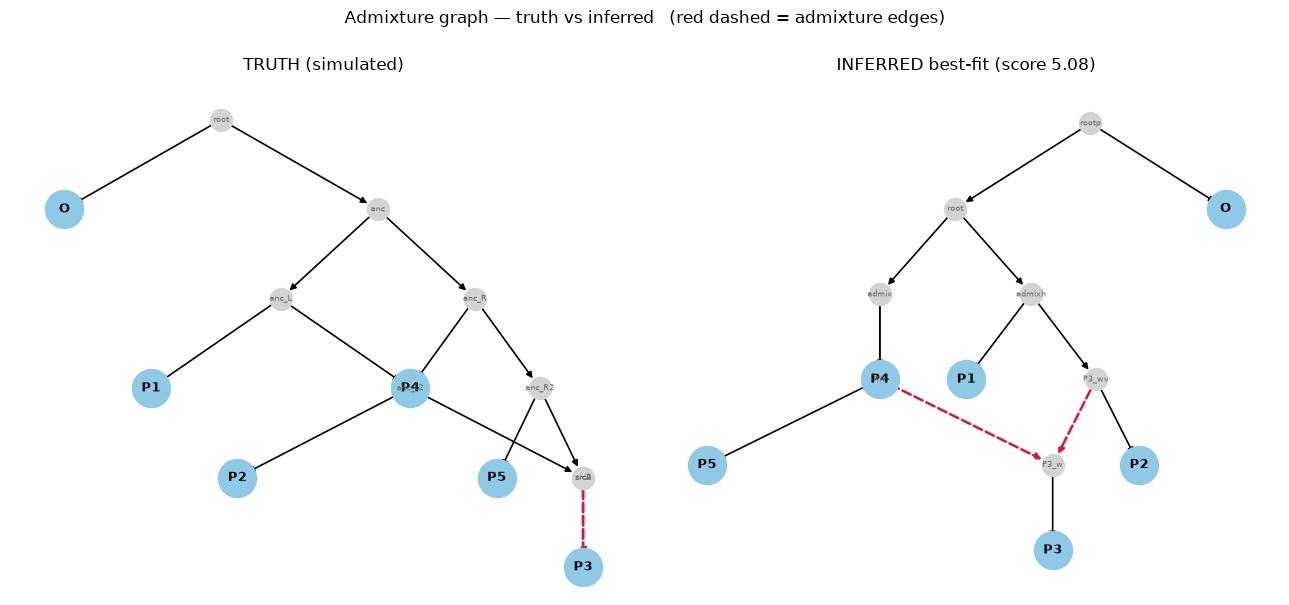

Both panels rendered by the SAME `draw_admixture_graph` (same layout & conventions);
a visual match therefore reflects a real structural match.


In [10]:
import matplotlib.pyplot as plt

def _layered_pos(edges):
    G = nx.DiGraph(); G.add_edges_from(edges)
    root = [n for n in G if G.in_degree(n) == 0][0]
    depth = {root: 0}
    for n in nx.topological_sort(G):
        for c in G.successors(n):
            depth[c] = max(depth.get(c, 0), depth[n] + 1)
    order = []
    def dfs(n):
        cs = list(G.successors(n))
        if not cs: order.append(n)
        for c in cs: dfs(c)
    dfs(root)
    xpos = {n: i for i, n in enumerate([n for n in order if G.out_degree(n) == 0])}
    for n in reversed(list(nx.topological_sort(G))):
        cs = list(G.successors(n))
        if cs: xpos[n] = sum(xpos[c] for c in cs) / len(cs)
    maxd = max(depth.values())
    return G, {n: (xpos[n], maxd - depth[n]) for n in G}

def draw_admixture_graph(edges, ax, title):
    # ONE function for both truth and inferred -> identical layout & conventions.
    G, pos = _layered_pos(edges)
    admix = {n for n in G if G.in_degree(n) == 2}
    e_norm = [(u, v) for u, v in G.edges if v not in admix]
    e_adm  = [(u, v) for u, v in G.edges if v in admix]
    leaves = [n for n in G if G.out_degree(n) == 0]
    intern = [n for n in G if G.out_degree(n) > 0]
    nx.draw_networkx_edges(G, pos, edgelist=e_norm, ax=ax, edge_color="black", arrows=True, arrowsize=9, width=1.2)
    nx.draw_networkx_edges(G, pos, edgelist=e_adm,  ax=ax, edge_color="crimson", style="dashed", arrows=True, arrowsize=9, width=1.8)
    nx.draw_networkx_nodes(G, pos, nodelist=intern, ax=ax, node_color="lightgrey", node_size=250)
    nx.draw_networkx_nodes(G, pos, nodelist=leaves, ax=ax, node_color="#8ecae6", node_size=750)
    nx.draw_networkx_labels(G, pos, labels={n: n for n in leaves}, ax=ax, font_size=9, font_weight="bold")
    nx.draw_networkx_labels(G, pos, labels={n: n for n in intern}, ax=ax, font_size=6, font_color="dimgrey")
    ax.set_title(title); ax.axis("off")

best = cands[0]
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
draw_admixture_graph(truth_edges, axes[0], "TRUTH (simulated)")
draw_admixture_graph([tuple(e) for e in best["edges"]], axes[1], f"INFERRED best-fit (score {best['score']:.2f})")
fig.suptitle("Admixture graph — truth vs inferred   (red dashed = admixture edges)", y=1.0)
plt.tight_layout(); plt.savefig(WORK / "truth_vs_inferred.png", dpi=120, bbox_inches="tight")
plt.show()
print("Both panels rendered by the SAME `draw_admixture_graph` (same layout & conventions);")
print("a visual match therefore reflects a real structural match.")

## Summary & next steps

If Step 5's gate passed, Step 6's residuals were small, and Step 8 reported **PASS**, the full
backbone is validated: a known graph round-trips from genotypes through f-statistics back to a
recovered topology.

**Where the ML project plugs in.** The f2 blocks written in Step 5 are the interface. To generate
training data at scale, swap Steps 1–5 for a fast analytic generator that emits the same f2 artifact
(graph → expected f-statistics directly, with noise) and reuse Steps 6–8 unchanged for validation.